# Delivery Dispatching Problem (DDP)

This notebook implements:
 1. A Gym environment for the DDP, deciding on shipping containers by truck or barge.
 2. A random policy (debugging baseline)
 3. The simple heuristic policy
 4. A simulation loop comparing both policies

The notebook is supplied together with the paper: "A Tutorial on Reinforcement Learning for Maritime Logistics" by Fabian Akkerman, Eduardo Lalla-Ruiz, and Martijn Mes.

Bibtex: 

```
@misc{akkerman_rl_tutorial,
    title={A Tutorial on Reinforcement Learning for Maritime Logistics},
    author={Fabian Akkerman and Eduardo Lalla-Ruiz and Martijn Mes},
    year={2026}}
```

In [1]:
# Imports
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from itertools import combinations
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model    import LinearRegression, Ridge
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
import warnings; warnings.filterwarnings('ignore')
from itertools import product as iproduct

import os, pickle
from stable_baselines3 import PPO
from stable_baselines3.common.env_util   import make_vec_env
from stable_baselines3.common.callbacks  import BaseCallback
from stable_baselines3.common.vec_env import VecNormalize


## Step 3: Implement a Simulation Model

 **State** `S[d, r, k]`: number of containers per type (destination, release day, window length).

 **Action** `a[d, k]`: number of released (r=0) containers of type (d, k) to load on the barge.
 Remaining k=0 containers are automatically trucked; k>0 containers not loaded stay on the dock.

 **Reward**: negative dispatching cost (fixed barge cost per destination subset + variable barge
 cost per container + variable truck cost per container).



In [2]:
#Configuration
config = {
    # --- Horizon & problem size ---
    'T':          7,
    'D':          3,
    'dest_names': ['R', 'G', 'B'],
    'R_max':      2,       # max release delay (days)
    'K_max':      2,       # max time window length
    'Q_barge':    8,      # barge capacity

    # --- Truck variable costs per destination [R, G, B] ---
    'c_truck':     [500., 1000., 700.],

    # --- Barge variable costs per destination [R, G, B] ---
    'c_barge_var': [100., 100., 100.],

    # --- Barge fixed costs per destination subset ---
    # Keys are frozensets of destination indices (0=R, 1=G, 2=B)
    'c_barge_fixed': {
        frozenset([0]):       250.,   # R
        frozenset([1]):       350.,   # G
        frozenset([2]):       450.,   # B
        frozenset([0, 1]):    900.,   # R+G
        frozenset([0, 2]):    600.,   # R+B
        frozenset([1, 2]):    700.,   # G+B
        frozenset([0, 1, 2]): 1000.,  # R+G+B
    },

    # --- End-of-horizon cleanup: multiplier on truck cost ---
    'cleanup_mult': 1.0,

    # --- Arrival distribution: number of containers per day ---
    # {n_containers: probability}
    'arrival_count_dist': {6: 0.2, 7: 0.5, 8: 0.3},

    # --- Destination probabilities [R, G, B] ---
    'dest_probs': [0.25, 0.50, 0.25],

    # --- Release day probabilities ---
    # Prob of container being immediately available (r=0)
    'p_released': 0.3,
    # Conditional distribution over r>0 values given not released
    # {r: probability}, must sum to 1
    'p_release_delay': {1: 0.6, 2: 0.4},

    # --- Time window probabilities ---
    # {k: probability} — window length on arrival
    # k=0: due today, k=1: due tomorrow, k=2: due in 2 days
    'k_probs': {0: 0.1, 1: 0.1, 2: 0.8},
}

In [3]:
class DDPEnv(gym.Env):
    """
    Gym environment for the Delivery Dispatching Problem (DDP).
    All parameters are passed via a config dict (see configuration cell above).
    """
    metadata = {'render_modes': ['human']}

    def __init__(self, config=None):
        super().__init__()
        cfg = config or {}

        # --- Problem parameters ---
        self.T          = cfg.get('T', 30)
        self.D          = cfg.get('D', 3)
        self.dest_names = cfg.get('dest_names', ['R', 'G', 'B'])
        self.R_max      = cfg.get('R_max', 2)
        self.K_max      = cfg.get('K_max', 2)
        self.Q_barge    = cfg.get('Q_barge', 10)

        # --- Costs ---
        self.c_truck        = np.array(cfg.get('c_truck',     [500., 1000., 700.]))
        self.c_barge_var    = np.array(cfg.get('c_barge_var', [100.,  100., 100.]))
        self.c_barge_fixed  = cfg.get('c_barge_fixed', {
            frozenset([0]):       250.,
            frozenset([1]):       350.,
            frozenset([2]):       450.,
            frozenset([0, 1]):    900.,
            frozenset([0, 2]):    600.,
            frozenset([1, 2]):    700.,
            frozenset([0, 1, 2]): 1000.,
        })
        self.cleanup_mult = cfg.get('cleanup_mult', 2.0)

        # --- Arrival distributions ---
        count_dist = cfg.get('arrival_count_dist', {6: 0.2, 7: 0.5, 8: 0.3})
        self.arrival_counts = list(count_dist.keys())
        self.arrival_probs  = list(count_dist.values())

        self.dest_probs = np.array(cfg.get('dest_probs', [0.25, 0.50, 0.25]))
        assert len(self.dest_probs) == self.D
        assert np.isclose(self.dest_probs.sum(), 1.0)

        self.p_released = cfg.get('p_released', 0.3)
        delay_dist      = cfg.get('p_release_delay', {1: 0.6, 2: 0.4})
        self.delay_vals  = list(delay_dist.keys())
        self.delay_probs = list(delay_dist.values())

        k_dist       = cfg.get('k_probs', {0: 0.1, 1: 0.1, 2: 0.8})
        self.k_vals  = list(k_dist.keys())
        self.k_probs = list(k_dist.values())

        # --- Gym spaces ---
        self.observation_space = spaces.Box(
            low=0, high=100,
            shape=(self.D * (self.R_max + 1) * (self.K_max + 1),),
            dtype=np.int32
        )
        self.action_space = spaces.Box(
            low=0, high=self.Q_barge,
            shape=(self.D * (self.K_max + 1),),
            dtype=np.int32
        )

        self.state = None
        self.t     = 0

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    def _obs(self):
        return self.state.flatten().astype(np.int32)

    def _sample_arrivals(self):
        """
        Sample today's container arrivals:
          1. Draw total number of containers from arrival_count_dist.
          2. For each container, independently draw destination, release day, window.
        """
        n = self.np_random.choice(self.arrival_counts, p=self.arrival_probs)
        for _ in range(n):
            d = self.np_random.choice(self.D, p=self.dest_probs)
            k = self.np_random.choice(self.k_vals, p=self.k_probs)
            if self.np_random.random() < self.p_released:
                r = 0
            else:
                r = self.np_random.choice(self.delay_vals, p=self.delay_probs)
                r = min(r, self.R_max)  # clip to R_max
            k = min(k, self.K_max)      # clip to K_max
            self.state[d, r, k] += 1

    def _transition(self):
        """
        Advance state by one day:
          r > 0 → decrement r (container approaches release, k frozen).
          r = 0 → decrement k (window shrinks).
          k = 0, r = 0 containers must have been dispatched before calling this.
        """
        new = np.zeros_like(self.state)
        for d in range(self.D):
            for r in range(self.R_max + 1):
                for k in range(self.K_max + 1):
                    n = int(self.state[d, r, k])
                    if n == 0:
                        continue
                    if r > 0:
                        new[d, r - 1, k] += n
                    else:
                        assert k > 0, (
                            f"Undispatched MustGo container at d={self.dest_names[d]}, "
                            f"r=0, k=0 before transition!"
                        )
                        new[d, 0, k - 1] += n
        self.state = new

    def _clip_action(self, barge_action):
        """Clip barge_action to available containers and barge capacity."""
        for d in range(self.D):
            for k in range(self.K_max + 1):
                barge_action[d, k] = min(int(barge_action[d, k]),
                                         int(self.state[d, 0, k]))
        total = int(barge_action.sum())
        if total > self.Q_barge:
            barge_action = np.floor(
                barge_action * self.Q_barge / total
            ).astype(int)
        return barge_action

    def _compute_cost(self, barge_action):
        """
        Compute dispatching cost:
          - Fixed barge cost for the subset of destinations visited.
          - Variable barge cost per container.
          - Variable truck cost for remaining k=0 containers.
        """
        cost = 0.0

        visited = frozenset(d for d in range(self.D) if barge_action[d].sum() > 0)
        if visited:
            cost += self.c_barge_fixed.get(visited, 0.0)
            for d in visited:
                cost += self.c_barge_var[d] * int(barge_action[d].sum())

        for d in range(self.D):
            n_truck = int(self.state[d, 0, 0]) - int(barge_action[d, 0])
            cost   += self.c_truck[d] * n_truck

        return cost

    # ------------------------------------------------------------------
    # Gym API
    # ------------------------------------------------------------------

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t     = 0
        self.state = self.np_random.integers(
            0, 3, size=(self.D, self.R_max + 1, self.K_max + 1)
        ).astype(np.int32)
        self.state[:, 1:, 0] = 0    # unreleased containers cannot have k=0
        return self._obs(), {}

    def step(self, action):
        barge_action = self._clip_action(
            action.reshape(self.D, self.K_max + 1).astype(int).copy()
        )

        cost = self._compute_cost(barge_action)

        # Remove dispatched containers from state
        for d in range(self.D):
            for k in range(self.K_max + 1):
                self.state[d, 0, k] -= barge_action[d, k]
        self.state[:, 0, 0] = 0     # remaining k=0 are trucked (cost already counted)

        terminated = (self.t >= self.T)
        if terminated:
            for d in range(self.D):
                for r in range(self.R_max + 1):
                    for k in range(self.K_max + 1):
                        cost += self.cleanup_mult * self.c_truck[d] * int(self.state[d, r, k])
        else:
            self._transition()
            self._sample_arrivals()
            self.t += 1

        info = {
            'cost':    cost,
            't':       self.t,
            'n_barge': int(barge_action.sum()),
        }
        return self._obs(), -cost, terminated, False, info

    def render(self):
        print(f"\n{'='*50}")
        print(f" Day {self.t:>3d}  |  Barge capacity: {self.Q_barge}")
        print(f"{'Dest':<6} {'r':>3} {'k':>3} {'#':>5}  {'Status'}")
        print(f"{'-'*50}")
        for d in range(self.D):
            for r in range(self.R_max + 1):
                for k in range(self.K_max + 1):
                    n = self.state[d, r, k]
                    if n > 0:
                        if r == 0 and k == 0:
                            note = "MUSTGO"
                        elif r == 0:
                            note = f"MayGo (due in {k}d)"
                        else:
                            note = f"Unreleased (r={r})"
                        print(f"{self.dest_names[d]:<6} {r:>3} {k:>3} {n:>5}  {note}")
        print(f"{'='*50}")

## Policies

### Random policy
Allocates a random feasible number of containers to the barge.

### Simple heuristic
 ```
 Phase 1 — For each destination (R, G, B):
     Load MustGo (k=0) containers on barge if capacity allows.
 Phase 2 — For destinations already on barge:
     Load MayGo containers in urgency order (k=1 first, then k=2, ...)
     if capacity allows.
 ```



In [4]:
def random_policy(env: DDPEnv) -> np.ndarray:
    """Randomly allocate released containers to the barge."""
    D, K_max = env.D, env.K_max
    action    = np.zeros((D, K_max + 1), dtype=int)
    barge_rem = env.Q_barge

    indices = [(d, k) for d in range(D) for k in range(K_max + 1)]
    env.np_random.shuffle(indices)

    for d, k in indices:
        avail = int(env.state[d, 0, k])
        if avail > 0 and barge_rem > 0:
            load           = int(env.np_random.integers(0, min(avail, barge_rem) + 1))
            action[d, k]  += load
            barge_rem     -= load

    return action.flatten()


def heuristic_policy(env: DDPEnv) -> np.ndarray:
    """
    Simple heuristic:
      Phase 1: for each destination, load MustGo (k=0, r=0) containers
               onto the barge while capacity allows.
      Phase 2: for destinations already on the barge, load MayGo (k>0, r=0)
               containers in ascending k order (most urgent first)
               while capacity allows.
    """
    state     = env.state
    D, K_max  = env.D, env.K_max
    action    = np.zeros((D, K_max + 1), dtype=int)
    barge_rem = env.Q_barge
    on_barge  = set()

    # Phase 1: MustGo
    for d in range(D):
        must_go = int(state[d, 0, 0])
        if must_go > 0 and barge_rem > 0:
            load         = min(must_go, barge_rem)
            action[d, 0] = load
            barge_rem   -= load
            on_barge.add(d)

    # Phase 2: MayGo (earliest due date first)
    for k in range(1, K_max + 1):
        for d in on_barge:
            may_go = int(state[d, 0, k])
            if may_go > 0 and barge_rem > 0:
                load         = min(may_go, barge_rem)
                action[d, k] = load
                barge_rem   -= load

    return action.flatten()

## Simulation runner

In [5]:
# %% Simulation function
def run_simulation(env: DDPEnv, policy_fn, n_episodes=50,
                   seed=0, verbose=False) -> pd.DataFrame:
    records = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        ep_cost = 0.0
        while True:
            if verbose:
                env.render()
            action = policy_fn(env)
            obs, reward, term, trunc, info = env.step(action)
            ep_cost += info['cost']
            records.append({
                'episode': ep,
                'step':    info['t'],
                'cost':    info['cost'],
                'n_barge': info['n_barge'],
            })
            if term or trunc:
                break
        if verbose:
            print(f"\n>>> Episode {ep+1} done | Total cost: {ep_cost:.1f}\n")
    df = pd.DataFrame(records)
    return df

## Step-by-step walkthrough (single episode, verbose)

In [6]:
# Single episode walkthrough
env = DDPEnv(config)
print("=== Single episode: heuristic policy ===")
_ = run_simulation(env, heuristic_policy, n_episodes=1, seed=42, verbose=True)

=== Single episode: heuristic policy ===

 Day   0  |  Barge capacity: 8
Dest     r   k     #  Status
--------------------------------------------------
R        0   1     2  MayGo (due in 1d)
R        0   2     1  MayGo (due in 2d)
R        1   1     1  Unreleased (r=1)
R        1   2     2  Unreleased (r=1)
R        2   1     2  Unreleased (r=2)
G        0   1     1  MayGo (due in 1d)
G        0   2     2  MayGo (due in 2d)
G        1   1     2  Unreleased (r=1)
G        1   2     2  Unreleased (r=1)
G        2   1     1  Unreleased (r=2)
B        0   0     2  MUSTGO
B        0   1     1  MayGo (due in 1d)
B        0   2     1  MayGo (due in 2d)
B        1   2     2  Unreleased (r=1)
B        2   1     1  Unreleased (r=2)
B        2   2     1  Unreleased (r=2)

 Day   1  |  Barge capacity: 8
Dest     r   k     #  Status
--------------------------------------------------
R        0   0     2  MUSTGO
R        0   1     2  MayGo (due in 1d)
R        0   2     4  MayGo (due in 2d)
R     

## Multi-episode comparison: heuristic vs. random

In [7]:
# %% Run both policies
N = 1000
env          = DDPEnv(config)
df_h         = run_simulation(env, heuristic_policy, n_episodes=N, seed=0)
df_r         = run_simulation(env, random_policy,    n_episodes=N, seed=0)
ep_h         = df_h.groupby('episode')['cost'].sum()
ep_r         = df_r.groupby('episode')['cost'].sum()

print(f"{'Policy':<12} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 54)
for label, ep in [('Heuristic', ep_h), ('Random', ep_r)]:
    print(f"{label:<12} {ep.mean():>10.1f} {ep.std():>10.1f} "
          f"{ep.min():>10.1f} {ep.max():>10.1f}")

Policy             Mean        Std        Min        Max
------------------------------------------------------
Heuristic       23683.9     2820.1    16200.0    34600.0
Random          30901.5     3202.2    23200.0    40950.0


## Visualisation

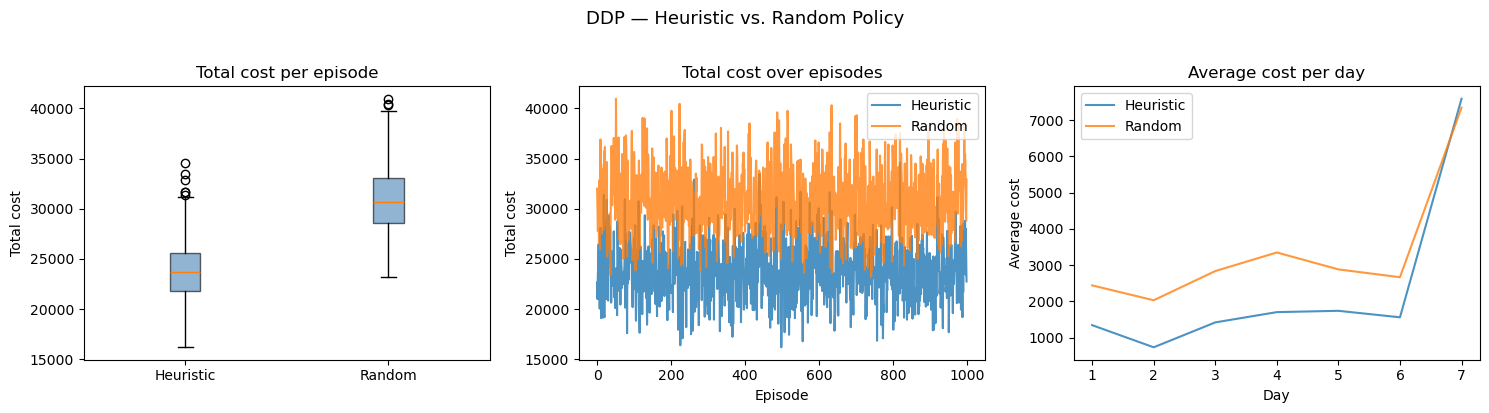

In [8]:
# %% Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].boxplot([ep_h, ep_r], tick_labels=['Heuristic', 'Random'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title('Total cost per episode')
axes[0].set_ylabel('Total cost')

axes[1].plot(ep_h.values, label='Heuristic', alpha=0.8)
axes[1].plot(ep_r.values, label='Random',    alpha=0.8)
axes[1].set_title('Total cost over episodes')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Total cost')
axes[1].legend()

daily_h = df_h.groupby('step')['cost'].mean()
daily_r = df_r.groupby('step')['cost'].mean()
axes[2].plot(daily_h.index, daily_h.values, label='Heuristic', alpha=0.8)
axes[2].plot(daily_r.index, daily_r.values, label='Random',    alpha=0.8)
axes[2].set_title('Average cost per day')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Average cost')
axes[2].legend()

plt.suptitle('DDP — Heuristic vs. Random Policy', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('ddp_policy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Fit a supervised ML model on static data
We run simulations under the heuristic policy, record state, cost, and actions,
engineer features, and train a Linear Regression model to predict the
**cost-to-go dispatching cost** from the state-action pair.
For each destination $d \in \{R, G, B\}$ we extract three inventory counts:

<div>

| Feature | Definition | Why it matters |
|---|---|---|
| `mustgo_d` | containers with $r=0, k=0$ | must be trucked today if not barged — direct cost driver |
| `maygo_d` | containers with $r=0, k>0$ | available but not yet urgent |
| `unrel_d` | containers with $r>0$ | locked, not yet dispatchable |
| `ind_mg_d` | $\mathbf{1}[\text{mustgo}_d > 0]$ | triggers fixed barge cost if barged |
| `urgency_d` | $\text{mustgo}_d / (\text{mustgo}_d + \text{maygo}_d)$ | fraction of released containers that are urgent |
| `mg_d × mg_d'` | pairwise MustGo indicators | captures whether barge fixed cost is shared across destinations |
| `total` | all containers in depot | proxy for future cost pressure |

</div>

In [9]:
# calculate features

def vfa_features(state, t, env):
    """State features + time features — input to V̂(s, t)."""
    D       = env.D
    mustgo  = state[:, 0, 0].astype(float)           # shape (D,)
    maygo   = state[:, 0, 1:].sum(axis=1).astype(float)
    unrel   = state[:, 1:, :].sum(axis=(1, 2)).astype(float)
    ind_mg  = (mustgo > 0).astype(float)
    urgency = np.where(mustgo + maygo > 0,
                       mustgo / (mustgo + maygo + 1e-9), 0.0)
    ixns    = [ind_mg[i] * ind_mg[j]
               for i, j in combinations(range(D), 2)]
    if D == 3:
        ixns.append(ind_mg[0] * ind_mg[1] * ind_mg[2])
    total   = float(state.sum())
    rem     = float(env.T - t)
    return np.concatenate([mustgo, maygo, unrel,
                           ind_mg, urgency,
                           ixns,
                           [total, float(t), rem]])


def vfa_feature_names(env):
    D, nm = env.D, env.dest_names
    names = (
        [f"mustgo_{n}"   for n in nm] +
        [f"maygo_{n}"    for n in nm] +
        [f"unrel_{n}"    for n in nm] +
        [f"ind_mg_{n}"   for n in nm] +
        [f"urgency_{n}"  for n in nm] +
        [f"mg_{nm[i]}x{nm[j]}" for i, j in combinations(range(D), 2)]
    )
    if D == 3:
        names.append(f"mg_{'x'.join(nm)}")
    return names + ['total', 't', 'steps_remaining']



In [10]:
#collect data

def collect_data(env, policy_fn, n_episodes=1000, seed=0):
    rows = []
    for ep in range(n_episodes):
        env.reset(seed=seed + ep)
        buf = []
        while True:
            s   = env.state.copy()
            t   = env.t
            act = policy_fn(env)
            _, _, term, trunc, info = env.step(act)
            buf.append({'s': s, 't': t, 'cost': info['cost']})
            if term or trunc:
                break
        # Backward pass: accumulate cost-to-go
        ctg = 0.0
        for row in reversed(buf):
            ctg       += row['cost']
            row['ctg'] = ctg
        rows.extend(buf)

    X = np.array([vfa_features(r['s'], r['t'], env) for r in rows], dtype=float)
    y = np.array([r['ctg'] for r in rows], dtype=float)
    return X, y


env  = DDPEnv(config)
X, y = collect_data(env, heuristic_policy, n_episodes=1000, seed=0)
print(f"Samples  : {len(y):,}")
print(f"Features : {X.shape[1]}  → {vfa_feature_names(env)}")
print(f"\nCost-to-go  mean={y.mean():.0f}  std={y.std():.0f}  "
      f"min={y.min():.0f}  max={y.max():.0f}")


Samples  : 8,000
Features : 22  → ['mustgo_R', 'mustgo_G', 'mustgo_B', 'maygo_R', 'maygo_G', 'maygo_B', 'unrel_R', 'unrel_G', 'unrel_B', 'ind_mg_R', 'ind_mg_G', 'ind_mg_B', 'urgency_R', 'urgency_G', 'urgency_B', 'mg_RxG', 'mg_RxB', 'mg_GxB', 'mg_RxGxB', 'total', 't', 'steps_remaining']

Cost-to-go  mean=18992  std=4235  min=6900  max=34600


R²(cost-to-go ~ t alone) = 0.6171


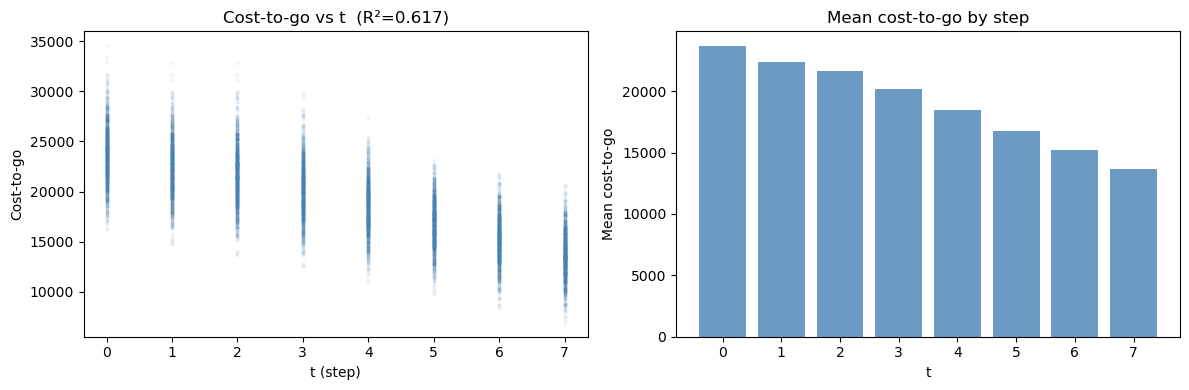

In [11]:
# How much does `t` explain on its own?

t_col  = X[:, vfa_feature_names(env).index('t')].reshape(-1, 1)
r2_t   = LinearRegression().fit(t_col, y).score(t_col, y)
t_vals = X[:, vfa_feature_names(env).index('t')].astype(int)
mean_by_t = {ti: y[t_vals == ti].mean() for ti in np.unique(t_vals)}

print(f"R²(cost-to-go ~ t alone) = {r2_t:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ti in sorted(np.unique(t_vals)):
    axes[0].scatter([ti] * int((t_vals == ti).sum()),
                    y[t_vals == ti], alpha=0.05, s=4, color='steelblue')
axes[0].set_xlabel('t (step)'); axes[0].set_ylabel('Cost-to-go')
axes[0].set_title(f'Cost-to-go vs t  (R²={r2_t:.3f})')

axes[1].bar(sorted(mean_by_t), [mean_by_t[k] for k in sorted(mean_by_t)],
            color='steelblue', alpha=0.8)
axes[1].set_xlabel('t'); axes[1].set_ylabel('Mean cost-to-go')
axes[1].set_title('Mean cost-to-go by step')
plt.tight_layout(); plt.show()

In [12]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Ridge':         Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=10.0))]),
    'Random Forest': Pipeline([('sc', StandardScaler()),
                                ('m', RandomForestRegressor(n_estimators=300,
                                      max_depth=10, n_jobs=-1, random_state=42))]),
}

results = {}
for name, pipe in models.items():
    pipe.fit(X_tr, y_tr)
    ptr, pte = pipe.predict(X_tr), pipe.predict(X_te)
    results[name] = dict(
        pipe=pipe, pred_te=pte,
        train_R2 = r2_score(y_tr, ptr),
        test_R2  = r2_score(y_te, pte),
        test_MAE = mean_absolute_error(y_te, pte),
        test_RMSE= np.sqrt(mean_squared_error(y_te, pte)),
    )

print(f"\n{'Model':<16} {'Train R²':>9} {'Test R²':>9} {'MAE':>9} {'RMSE':>9}")
print(f"{'t-only baseline':<16} {r2_t:>9.4f} {r2_t:>9.4f}   {'—':>8}   {'—':>8}")
print('-' * 56)
for name, r in results.items():
    print(f"{name:<16} {r['train_R2']:>9.4f} {r['test_R2']:>9.4f} "
          f"{r['test_MAE']:>9.1f} {r['test_RMSE']:>9.1f}")



Model             Train R²   Test R²       MAE      RMSE
t-only baseline     0.6171    0.6171          —          —
--------------------------------------------------------
Ridge               0.7541    0.7326    1717.0    2185.7
Random Forest       0.8635    0.7415    1665.9    2148.9


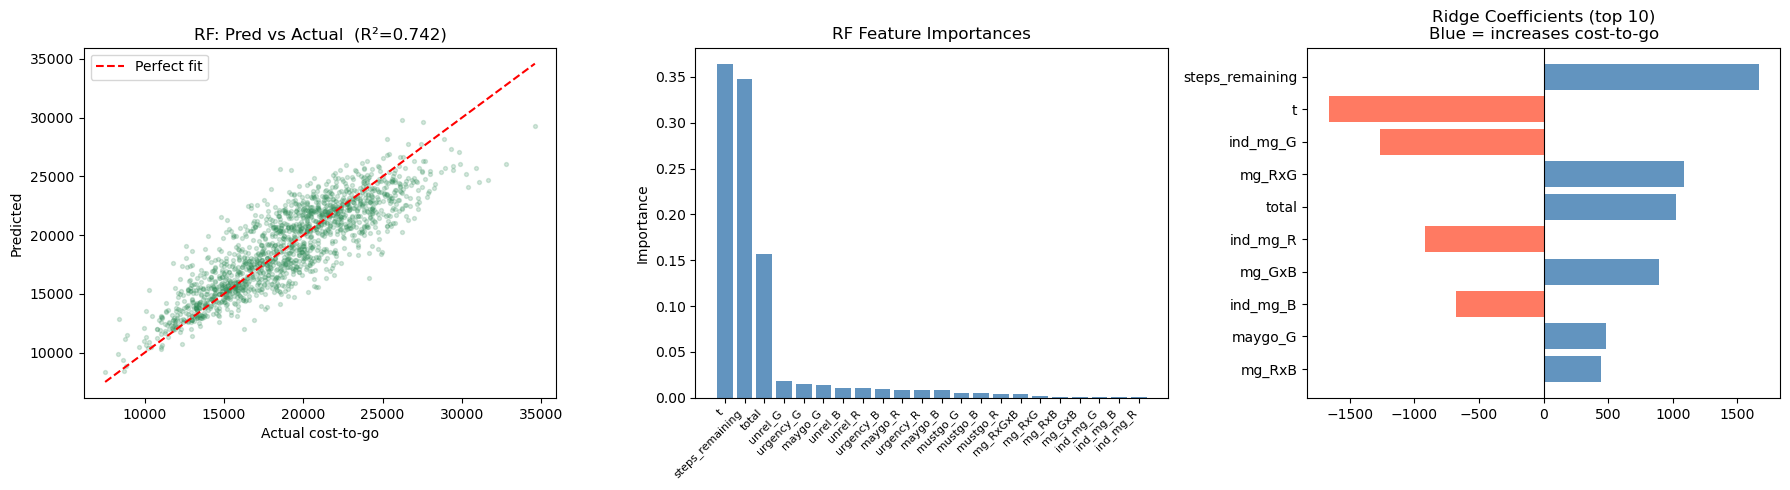

In [13]:
## Diagnostics

fn  = vfa_feature_names(env)
rf  = results['Random Forest']['pipe'].named_steps['m']
rid = results['Ridge']['pipe'].named_steps['m']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Pred vs actual (RF) ---
ax = axes[0]
ax.scatter(y_te, results['Random Forest']['pred_te'],
           alpha=0.2, s=8, color='seagreen')
mn, mx = y_te.min(), y_te.max()
ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Actual cost-to-go'); ax.set_ylabel('Predicted')
ax.set_title(f"RF: Pred vs Actual  (R²={results['Random Forest']['test_R2']:.3f})")
ax.legend()

# --- Feature importances (RF) ---
ax  = axes[1]
imp = rf.feature_importances_
top = np.argsort(imp)[::-1]
ax.bar(np.array(fn)[top], imp[top], color='steelblue', alpha=0.85)
ax.set_xticklabels(np.array(fn)[top], rotation=45, ha='right', fontsize=8)
ax.set_title('RF Feature Importances')
ax.set_ylabel('Importance')

# --- Ridge coefficients ---
ax    = axes[2]
coef  = rid.coef_
top_r = np.argsort(np.abs(coef))[::-1][:10]
colors = ['steelblue' if c > 0 else 'tomato' for c in coef[top_r]]
ax.barh(np.array(fn)[top_r], coef[top_r], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.invert_yaxis()
ax.set_title('Ridge Coefficients (top 10)\nBlue = increases cost-to-go')

plt.tight_layout()
plt.savefig('ddp_step5_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Fit a supervised ML model on static data.

We use the trained VFA $\hat{V}(S_t, t)$ to guide dispatching decisions
via a **one-step lookahead**:

$$a_t^* = \arg\min_{a \in \mathcal{X}(S_t)} \left[ C(S_t, a) + \hat{V}(S_t^a,\, t+1) \right]$$

where $S_t^a$ is the post-decision state after applying $a$.

The decision of *which due-date class* to send per
destination is rule-based, always dispatch the most urgent containers
first ($k=0$ before $k=1$, etc.).  The only genuine decision is
*how many* containers of each colour to put on the barge:

$$\mathbf{n} = (n_R,\, n_G,\, n_B), \quad n_d \in \mathbb{N},
  \quad \sum_d n_d \leq Q^{\text{barge}}$$
The number of feasible $\mathbf{n}$ is
$\binom{Q^{\text{barge}}+D}{D} = \binom{11}{3} = 165$,
so we enumerate all of them exactly at every step.

Given $n_d$, the within-destination loading is greedy by urgency:
fill $k=0$ first, then $k=1$, up to $n_d$ total.


In [14]:
def enumerate_n_vecs(env):
    """
    Yield all (n_R, n_G, n_B) with sum <= Q_barge and
    n_d <= total released containers available for destination d.
    """
    D, Q = env.D, env.Q_barge
    avail = [int(env.state[d, 0, :].sum()) for d in range(D)]
    for n_vec in iproduct(*[range(min(avail[d], Q) + 1) for d in range(D)]):
        if sum(n_vec) <= Q:
            yield n_vec


def n_vec_to_action(n_vec, env):
    """
    Convert a per-destination count vector to a full action array,
    loading the most urgent containers first (lowest k first).
    """
    D, K = env.D, env.K_max
    act  = np.zeros((D, K + 1), dtype=int)
    for d, n in enumerate(n_vec):
        rem = n
        for k in range(K + 1):
            av = int(env.state[d, 0, k])
            if av > 0 and rem > 0:
                load      = min(av, rem)
                act[d, k] = load
                rem      -= load
    return act.flatten()

# VFA lookahead policy
def post_decision_state(env, ba):
    """Post-decision state after barge action ba (D × K+1 array), without modifying env."""
    post = env.state.copy()
    for d in range(env.D):
        for k in range(env.K_max + 1):
            post[d, 0, k] -= min(int(ba[d, k]), int(post[d, 0, k]))
    post[:, 0, 0] = 0
    return post


def vfa_lookahead_policy(env, vfa_pipe):
    """
    Exact enumeration over the reduced action space.
    Score each action as  C(S_t, a) + V̂(S_t^a, t+1)  and return the best.
    """
    t_next     = min(env.t + 1, env.T)
    best_act   = None
    best_score = np.inf

    # Batch all post-decision feature vectors for a single predict() call
    n_vecs  = list(enumerate_n_vecs(env))
    acts    = [n_vec_to_action(nv, env) for nv in n_vecs]
    feats   = []
    imm_costs = []

    for act in acts:
        ba  = env._clip_action(act.reshape(env.D, env.K_max + 1).astype(int).copy())
        imm = env._compute_cost(ba)
        post = post_decision_state(env, ba)
        feats.append(vfa_features(post, t_next, env))
        imm_costs.append(imm)

    X_cand  = np.array(feats)
    v_hats  = vfa_pipe.predict(X_cand)           # single batched call
    scores  = np.array(imm_costs) + v_hats
    best_i  = int(np.argmin(scores))
    return acts[best_i]

In [15]:
def eval_policy(policy_fn, n_ep=50, seed=999):
    env2  = DDPEnv(config)
    costs = []
    for ep in range(n_ep):
        env2.reset(seed=seed + ep)
        total = 0.0
        while True:
            _, _, term, trunc, info = env2.step(policy_fn(env2))
            total += info['cost']
            if term or trunc:
                break
        costs.append(total)
    return np.array(costs)


vfa_pipe = results['Random Forest']['pipe']

print("Evaluating policies (500 episodes each) …")
costs = {
    'Random':     eval_policy(random_policy),
    'Heuristic':  eval_policy(heuristic_policy),
    'ML':        eval_policy(lambda e: vfa_lookahead_policy(e, vfa_pipe)),
}

print(f"\n{'Policy':<14} {'Mean':>9} {'Std':>8} {'Min':>9} {'Max':>9}  {'vs Heuristic':>13}")
print('-' * 65)
h_mean = costs['Heuristic'].mean()
for label, c in costs.items():
    diff = f"{(c.mean() - h_mean) / h_mean * 100:+.1f}%"
    print(f"{label:<14} {c.mean():>9.1f} {c.std():>8.1f} "
          f"{c.min():>9.1f} {c.max():>9.1f}  {diff:>13}")

Evaluating policies (500 episodes each) …

Policy              Mean      Std       Min       Max   vs Heuristic
-----------------------------------------------------------------
Random           32399.0   2814.3   25950.0   38950.0         +32.9%
Heuristic        24383.0   2554.3   18350.0   29500.0          +0.0%
ML               24554.0   1442.1   21000.0   27300.0          +0.7%


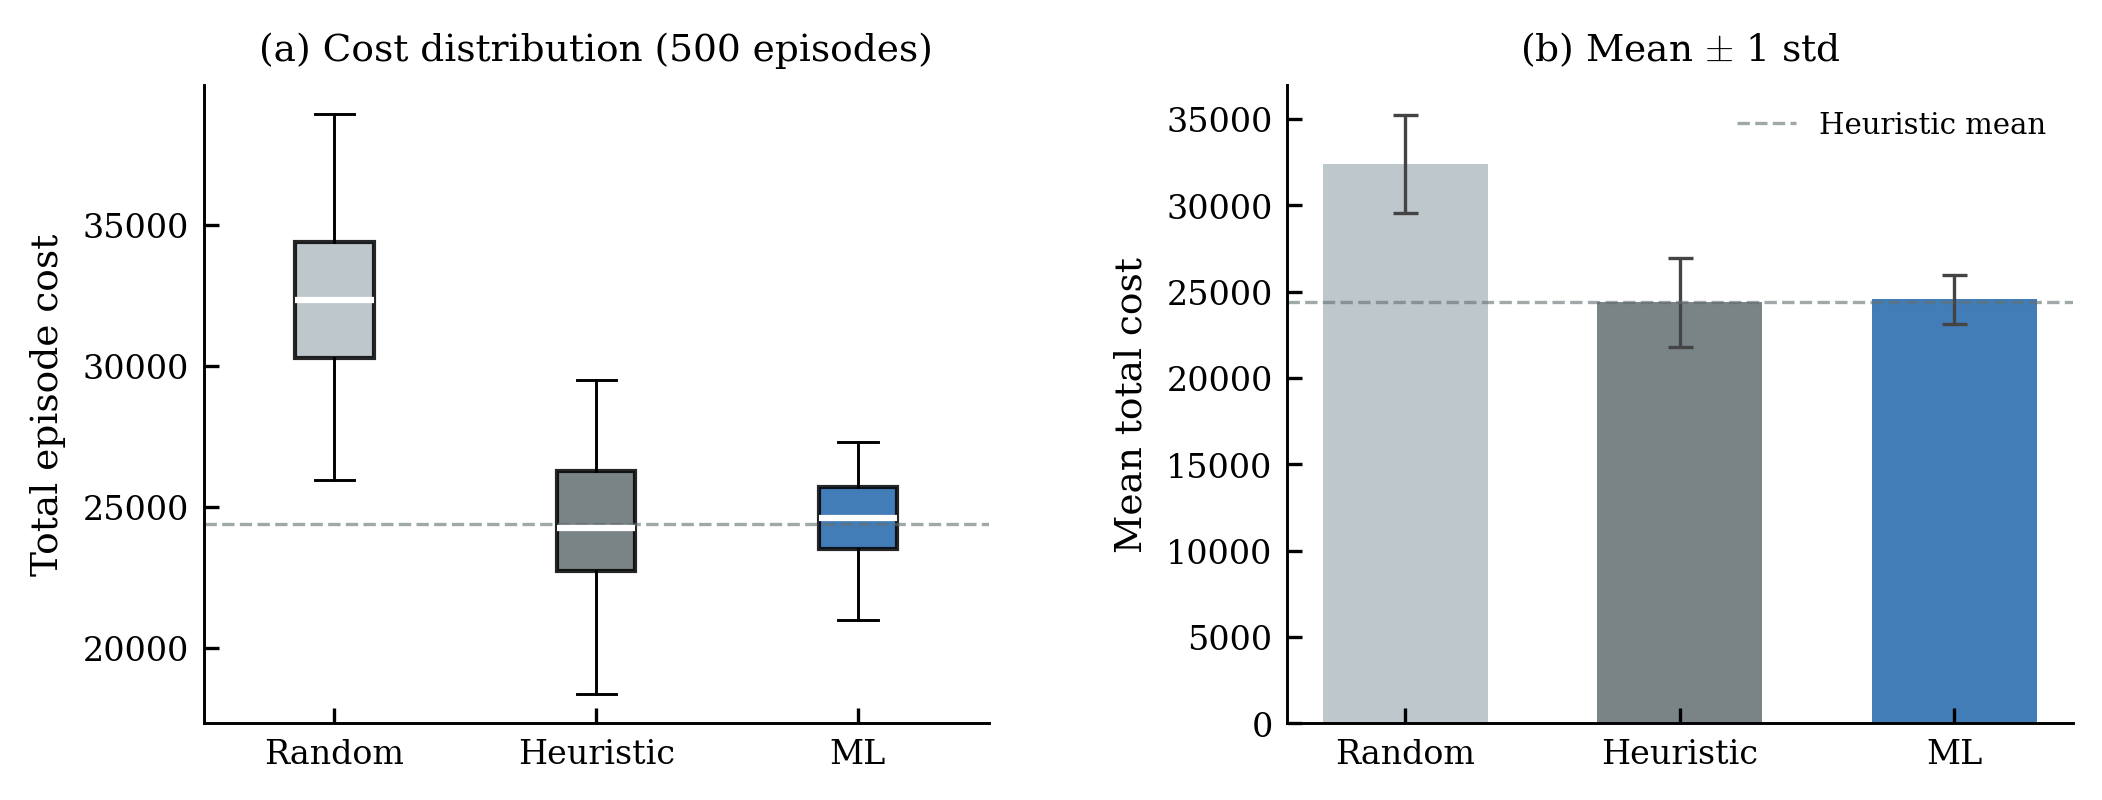

In [16]:
plt.rcParams.update({
'font.family': 'serif', 'font.serif': ['Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm', 'font.size': 9, 'axes.titlesize': 9,
    'axes.labelsize': 9, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'axes.linewidth': 0.7, 'xtick.direction': 'in', 'ytick.direction': 'in',
    'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 300,
})

labels   = list(costs.keys())
c_arrays = list(costs.values())
colors   = ['#b2bec3', '#636e72', '#2166ac']

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8),
                          gridspec_kw=dict(wspace=0.38, left=0.08,
                                           right=0.97, top=0.90, bottom=0.14))
# (a) boxplot
bp = axes[0].boxplot(c_arrays, labels=labels, patch_artist=True,
                      medianprops=dict(color='white', lw=1.5),
                      whiskerprops=dict(lw=0.7), capprops=dict(lw=0.7),
                      flierprops=dict(marker='o', ms=2, alpha=0.4,
                                      markeredgewidth=0))
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor(col); patch.set_alpha(0.85)
axes[0].set_ylabel('Total episode cost')
axes[0].set_title('(a) Cost distribution (500 episodes)')
axes[0].axhline(h_mean, color='#636e72', lw=0.8, ls='--', alpha=0.6)

# (b) mean ± 1 std
means = [c.mean() for c in c_arrays]
stds  = [c.std()  for c in c_arrays]
axes[1].bar(np.arange(len(labels)), means, yerr=stds,
             color=colors, alpha=0.85, width=0.6, linewidth=0,
             error_kw=dict(lw=0.8, capsize=3, capthick=0.8, ecolor='#444444'))
axes[1].set_xticks(np.arange(len(labels)))
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Mean total cost')
axes[1].set_title('(b) Mean $\\pm$ 1 std')
axes[1].axhline(h_mean, color='#636e72', lw=0.8, ls='--', alpha=0.6,
                 label='Heuristic mean')
axes[1].legend(frameon=False, fontsize=7)

plt.savefig('ddp_step5_policy_compare.pdf', dpi=300, bbox_inches='tight')
plt.savefig('ddp_step5_policy_compare.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 6: RL model

In [17]:
class DDPEnvFeat(DDPEnv):
    def __init__(self, config=None):
        super().__init__(config)
        # Observation space
        dummy_state = np.zeros((self.D, self.R_max + 1, self.K_max + 1), dtype=np.int32)
        n_feat = len(vfa_features(dummy_state, 0, self))
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(n_feat,),
            dtype=np.float32
        )
        # Reduced action space: just per-destination counts
        self.action_space = spaces.Box(
            low=0, high=self.Q_barge,
            shape=(self.D,),
            dtype=np.float32
        )

    def _obs(self):
        return vfa_features(self.state, self.t, self).astype(np.float32)

    def step(self, action):
        # Convert D-dim count vector to full D×(K+1) action, urgent-first
        full_action = n_vec_to_action(
            np.clip(np.round(action), 0, self.Q_barge).astype(int),
            self
        )
        return super().step(full_action)

In [33]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
import warnings; warnings.filterwarnings('ignore')


class MLPGaussianPolicy:
    def __init__(self, n_obs, n_act, max_act, hidden=64, lr=1e-3, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, 0.1, (hidden, n_obs)) * np.sqrt(2/n_obs)
        self.b1 = np.zeros(hidden)
        self.W2 = rng.normal(0, 0.1, (n_act, hidden)) * np.sqrt(2/hidden)
        self.b2 = np.zeros(n_act)
        self.log_std = np.full(n_act, np.log(0.5))
        self.lr = lr
        self.max_act = float(max_act)

    def _forward(self, obs):
        h = np.tanh(self.W1 @ obs + self.b1)
        return np.clip(self.W2 @ h + self.b2, 0.0, self.max_act), h

    def mean(self, obs):
        mu, _ = self._forward(obs)
        return mu

    def std(self):
        return np.exp(np.clip(self.log_std, -3.0, 1.0))

    def sample(self, obs, rng):
        return self.mean(obs) + self.std() * rng.standard_normal(len(self.log_std))

    def update(self, episodes, baseline, gamma, max_grad_norm=1.0):
        """
        Batch REINFORCE update with:
          - return normalisation (zero mean, unit std within batch)
          - gradient norm clipping
        """
        dW_mu     = np.zeros_like(self.W_mu)
        d_log_std = np.zeros_like(self.log_std)

        # Collect all (obs, act, advantage) tuples across the batch
        all_tuples = []
        for ep in episodes:
            rewards = np.array([r for _, _, r in ep])
            G, returns = 0.0, []
            for r in reversed(rewards):
                G = r + gamma * G
                returns.insert(0, G)
            returns = np.array(returns)
            for (obs, act, _), Gt in zip(ep, returns):
                all_tuples.append((obs, act, Gt))

        # Normalise returns across the whole batch
        rets = np.array([t[2] for t in all_tuples])
        rets = (rets - rets.mean()) / (rets.std() + 1e-8)

        for (obs, act, _), adv in zip(all_tuples, rets):
            mu, sigma = self.mean(obs), self.std()
            dW_mu     += adv * np.outer((act - mu) / sigma**2, obs)
            d_log_std += adv * ((act - mu)**2 / sigma**2 - 1.0)

        n = len(all_tuples)
        dW_mu     /= n
        d_log_std /= n

        # Gradient norm clipping
        norm = np.sqrt((dW_mu**2).sum() + (d_log_std**2).sum())
        if norm > max_grad_norm:
            dW_mu     *= max_grad_norm / norm
            d_log_std *= max_grad_norm / norm

        self.W_mu    += self.lr * dW_mu
        self.log_std += self.lr * d_log_std


def clip_round_action(raw_action, env):
    """Works for both DDPEnv and DDPEnvFeat."""
    safe = np.clip(raw_action, -1e6, 1e6)
    act  = np.clip(np.round(safe), 0, env.Q_barge).astype(np.int32)
    if isinstance(env, DDPEnvFeat):
        return act          # shape (D,) — DDPEnvFeat.step handles the rest
    return env._clip_action(act.reshape(env.D, env.K_max + 1).copy()).flatten()


def train_reinforce(env, n_iter=300, batch_size=20,
                    gamma=1.0, lr=5e-4, seed=0):
    n_obs = env.observation_space.shape[0]
    n_act = env.action_space.shape[0]
    policy = LinearGaussianPolicy(n_obs, n_act,
                                  max_act=env.Q_barge, lr=lr, seed=seed)
    rng    = np.random.default_rng(seed)

    returns_log = []
    baseline    = 0.0
    alpha_b     = 0.15          # baseline EMA smoothing

    for it in range(n_iter):
        batch = []
        ep_returns = []

        for b in range(batch_size):
            obs, _ = env.reset(seed=seed + it * batch_size + b)
            ep, total_r = [], 0.0
            while True:
                raw = policy.sample(obs.astype(float), rng)
                act = clip_round_action(raw, env)
                next_obs, reward, term, trunc, _ = env.step(act)
                ep.append((obs.astype(float), raw, reward))
                total_r += reward
                obs = next_obs
                if term or trunc:
                    break
            batch.append(ep)
            ep_returns.append(total_r)

        mean_ret = np.mean(ep_returns)
        baseline = (1 - alpha_b) * baseline + alpha_b * mean_ret
        policy.update(batch, baseline, gamma)

        returns_log.append(mean_ret)
        if (it + 1) % 50 == 0:
            print(f"  REINFORCE iter {it+1:>4d} | "
                  f"mean return: {mean_ret:>10.1f}  (baseline: {baseline:.1f})")

    return policy, returns_log


print("Training REINFORCE …")
#env_train = DDPEnv(config)
env_train = DDPEnvFeat(config)
rf_policy, rf_log = train_reinforce(env_train, n_iter=1000,
                                     batch_size=128, lr=5e-3, seed=0)

Training REINFORCE …
  REINFORCE iter   50 | mean return:   -34249.6  (baseline: -35588.6)
  REINFORCE iter  100 | mean return:   -26427.3  (baseline: -27116.5)
  REINFORCE iter  150 | mean return:   -26382.4  (baseline: -26135.7)
  REINFORCE iter  200 | mean return:   -26175.0  (baseline: -26201.5)
  REINFORCE iter  250 | mean return:   -26170.7  (baseline: -25976.8)
  REINFORCE iter  300 | mean return:   -26041.0  (baseline: -25964.1)
  REINFORCE iter  350 | mean return:   -26008.2  (baseline: -26056.9)
  REINFORCE iter  400 | mean return:   -26325.4  (baseline: -26146.4)
  REINFORCE iter  450 | mean return:   -26005.1  (baseline: -26073.0)
  REINFORCE iter  500 | mean return:   -25596.1  (baseline: -25816.7)
  REINFORCE iter  550 | mean return:   -26016.0  (baseline: -25962.9)
  REINFORCE iter  600 | mean return:   -25816.8  (baseline: -26021.2)
  REINFORCE iter  650 | mean return:   -25969.5  (baseline: -26167.4)
  REINFORCE iter  700 | mean return:   -26308.2  (baseline: -26202.2)

In [24]:
SAVE_DIR = "ppo_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

class ReturnLogger(BaseCallback):
    """Collect mean episode return every `check_freq` calls."""
    def __init__(self, check_freq=500, save_freq=100_000, save_dir=SAVE_DIR):
        super().__init__()
        self.check_freq = check_freq
        self.save_freq  = save_freq
        self.save_dir   = save_dir
        self.log = []

    def _on_step(self):
        if self.n_calls % self.check_freq == 0:
            if 'episode' in self.locals.get('infos', [{}])[0]:
                r = self.locals['infos'][0]['episode']['r']
                self.log.append((self.n_calls, r))

        # periodic model + normaliser checkpoint
        if self.n_calls % self.save_freq == 0:
            tag = f"step_{self.n_calls:08d}"
            self.model.save(os.path.join(self.save_dir, f"ppo_{tag}"))
            # save the VecNormalize statistics alongside the model
            self.model.get_vec_normalize_env().save(
                os.path.join(self.save_dir, f"vecnorm_{tag}.pkl")
            )
        return True

    def save_log(self, path):
        with open(path, "wb") as f:
            pickle.dump(self.log, f)

# ── envs ──────────────────────────────────────────────────────────────────────
vec_env = make_vec_env(lambda: DDPEnvFeat(config), n_envs=4, seed=0)
vec_env = VecNormalize(vec_env, norm_obs=False, norm_reward=True, clip_reward=10.0)

callback = ReturnLogger(check_freq=500, save_freq=100_000)

ppo_model = PPO(
    policy        = 'MlpPolicy',
    env           = vec_env,
    learning_rate = 3e-4,
    n_steps       = 112,
    batch_size    = 64,
    n_epochs      = 10,
    gamma         = 1.0,
    gae_lambda    = 0.95,
    clip_range    = 0.2,
    ent_coef      = 0.005,
    policy_kwargs = dict(net_arch=dict(pi=[128, 128], vf=[128, 128])),
    verbose       = 0,
    seed          = 0,
)

TOTAL_STEPS = 1_500_000
print(f"Training PPO ({TOTAL_STEPS:,} steps) …")
from rich.progress import Progress
from rich import get_console
get_console()._live = None 
ppo_model.learn(total_timesteps=TOTAL_STEPS, callback=callback, progress_bar=True)
print("PPO training complete.")

# ── save final model, normaliser, and training log
ppo_model.save(os.path.join(SAVE_DIR, "ppo_final"))
vec_env.save(os.path.join(SAVE_DIR, "vecnorm_final.pkl"))
callback.save_log(os.path.join(SAVE_DIR, "return_log.pkl"))
print(f"Saved model, VecNormalize stats, and return log to '{SAVE_DIR}/'")

Training PPO (1,500,000 steps) …

Output()

PPO training complete.

Saved model, VecNormalize stats, and return log to 'ppo_checkpoints/'

In [34]:
# %%
def eval_policy(policy_fn, n_ep=500, seed=999):
   # env2  = DDPEnv(config)
    env2 = DDPEnvFeat(config)
    costs = []
    for ep in range(n_ep):
        obs, _ = env2.reset(seed=seed + ep)
        total  = 0.0
        while True:
            act = policy_fn(env2, obs)
            obs, _, term, trunc, info = env2.step(act)
            total += info['cost']
            if term or trunc:
                break
        costs.append(total)
    return np.array(costs)


# Wrap each policy
def wrap_random(env, obs):
    return env.action_space.sample()  # 

def wrap_heuristic(env, obs):
    full_act = heuristic_policy(env)       
    # sum across urgency classes per destination to get (D,) counts
    return full_act.reshape(env.D, env.K_max + 1).sum(axis=1).astype(np.float32)

def wrap_vfa(env, obs):
    full_act = vfa_lookahead_policy(env, vfa_pipe)   # shape (D*(K+1),)
    return full_act.reshape(env.D, env.K_max + 1).sum(axis=1).astype(np.float32)

def wrap_ppo(env, obs):
    act, _ = ppo_model.predict(obs, deterministic=True)
    return act   # DDPEnvFeat.step() handles conversion internally

def wrap_reinforce(env, obs):
    rng = np.random.default_rng()
    raw = rf_policy.sample(obs.astype(float), rng)
    return raw   # same — step() handles it


print("Evaluating all policies (500 episodes each) …")
all_costs = {
   'Random':     eval_policy(wrap_random),
    'Heuristic':  eval_policy(wrap_heuristic),
    'ML':        eval_policy(wrap_vfa),
    'REINFORCE':  eval_policy(wrap_reinforce),
    'PPO':        eval_policy(wrap_ppo),
}



h_mean = all_costs['Heuristic'].mean() if 'Heuristic' in all_costs else None

print(f"\n{'Policy':<14} {'Mean':>9} {'Std':>8} {'Min':>9} {'Max':>9}  {'vs Heuristic':>13}")
print('-' * 68)
for label, c in all_costs.items():
    diff = f"{(c.mean() - h_mean) / h_mean * 100:+.1f}%" if h_mean else "N/A"
    print(f"{label:<14} {c.mean():>9.1f} {c.std():>8.1f} "
          f"{c.min():>9.1f} {c.max():>9.1f}  {diff:>13}")




Evaluating all policies (500 episodes each) …

Policy              Mean      Std       Min       Max   vs Heuristic
--------------------------------------------------------------------
Random           33860.3   4775.5   18500.0   49100.0         +43.5%
Heuristic        23591.0   2764.0   16600.0   31700.0          +0.0%
ML               24288.3   1552.7   20500.0   29100.0          +3.0%
REINFORCE        26042.1   2881.4   19900.0   39150.0         +10.4%
PPO              21554.8   2213.8   16750.0   30650.0          -8.6%


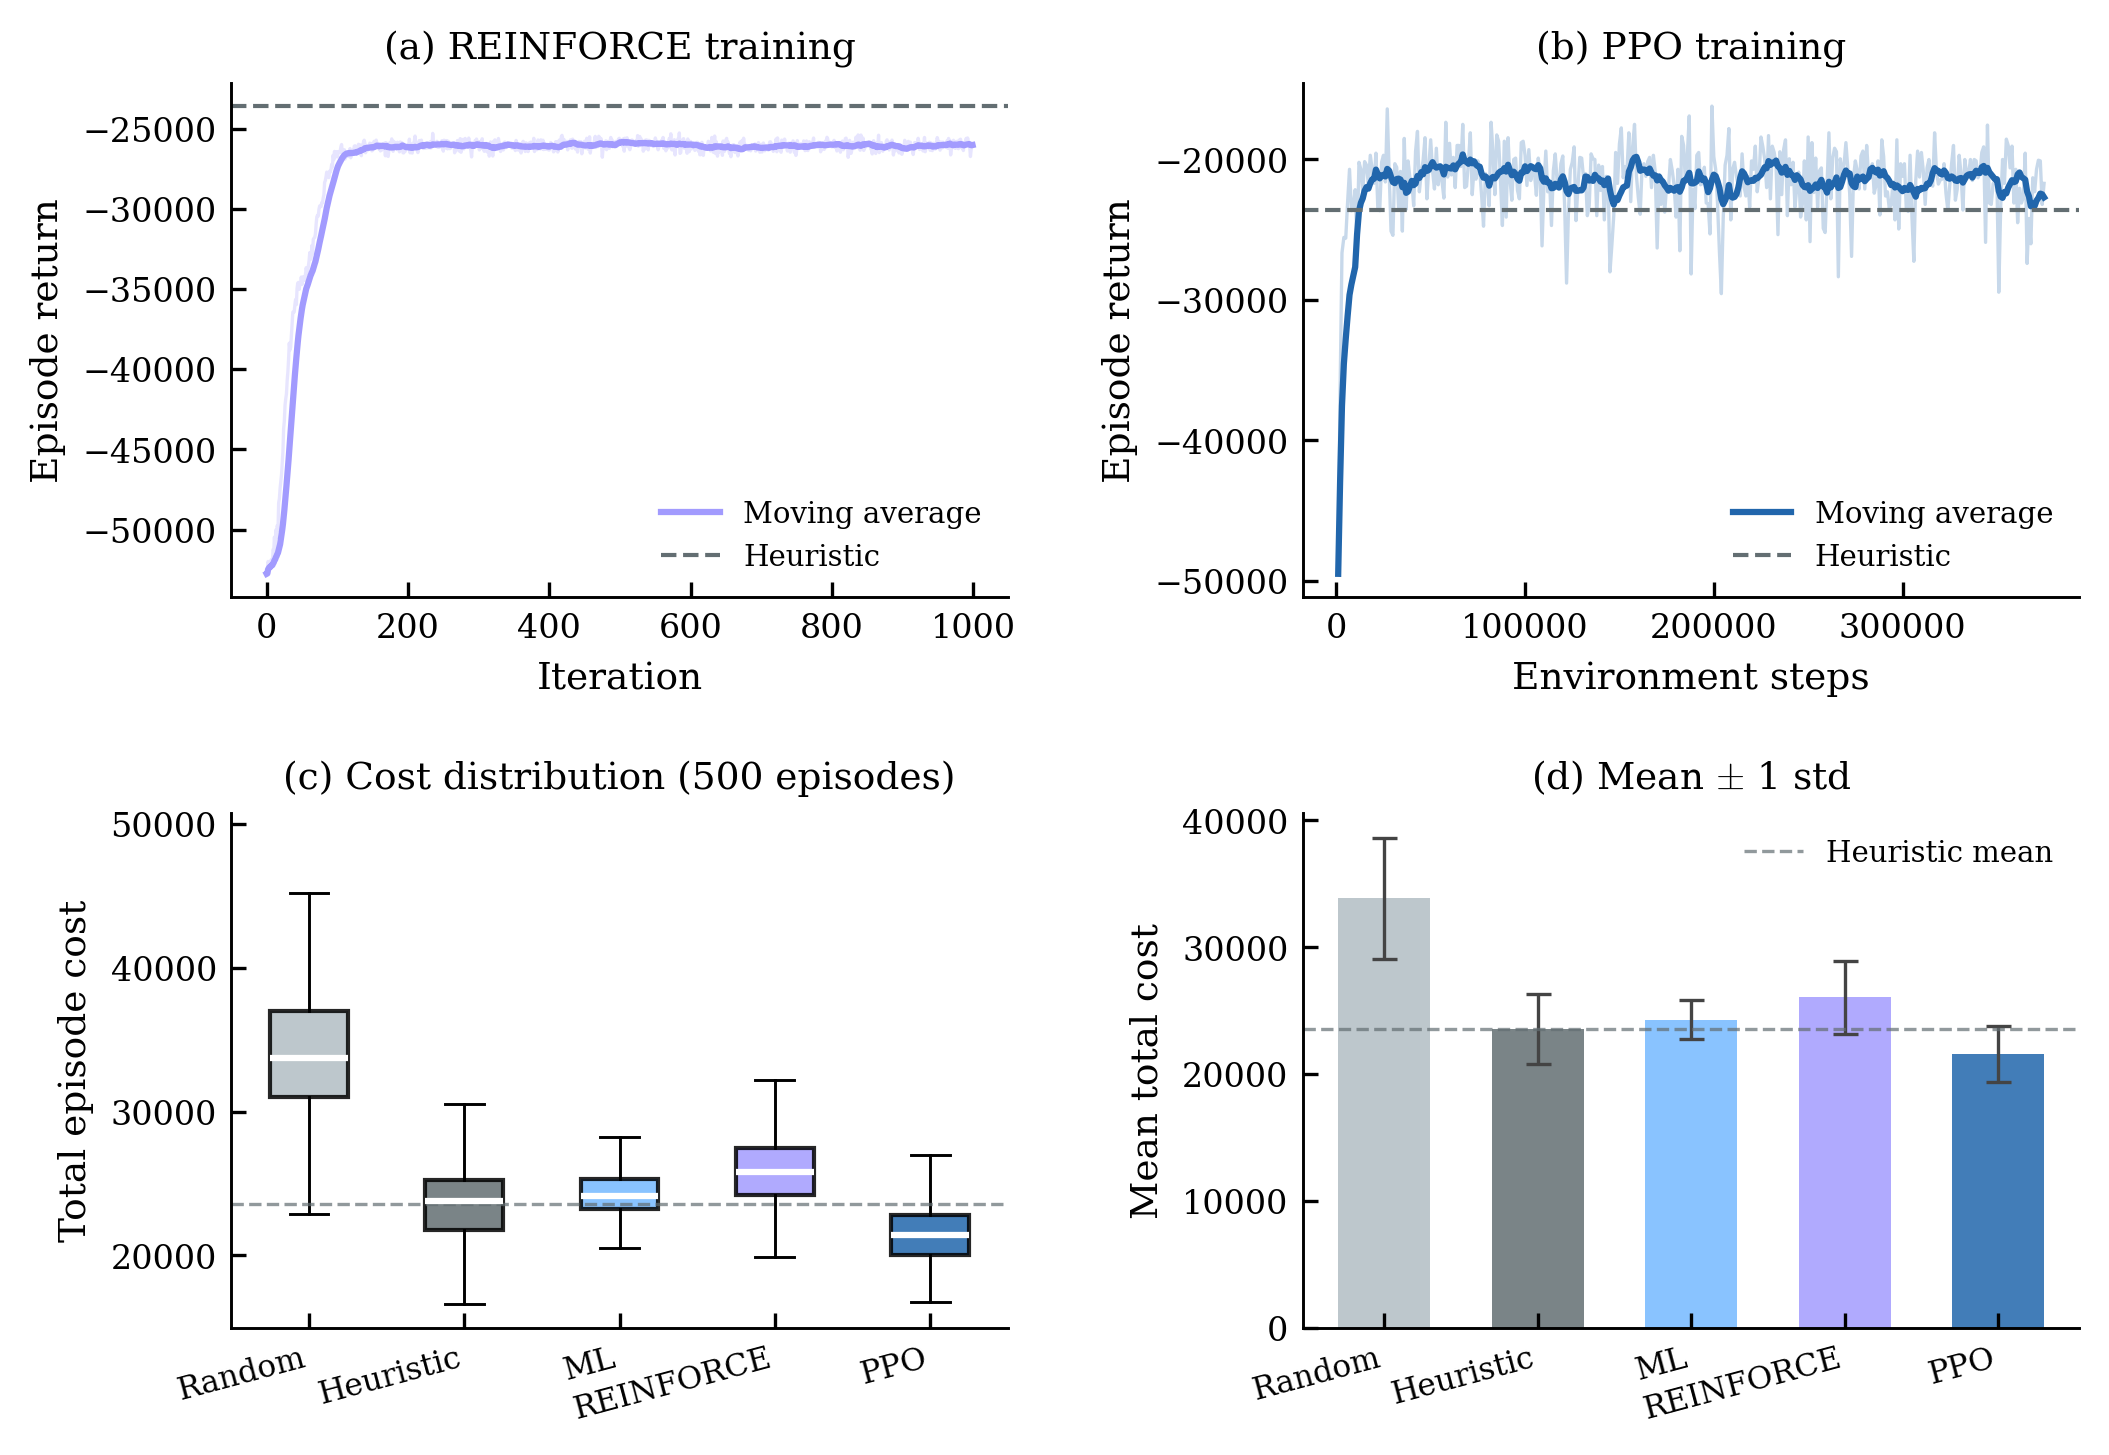

In [36]:
plt.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm', 'font.size': 9, 'axes.titlesize': 9,
    'axes.labelsize': 9, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'axes.linewidth': 0.7, 'xtick.direction': 'in', 'ytick.direction': 'in',
    'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 300,
})

COLS = {'Random': '#b2bec3', 'Heuristic': '#636e72',
        'ML': '#74b9ff', 'REINFORCE': '#a29bfe', 'PPO': '#2166ac'}

fig = plt.figure(figsize=(7.0, 5.0))
gs  = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.38,
                        left=0.09, right=0.97, top=0.93, bottom=0.10)
ax0 = fig.add_subplot(gs[0, 0])   # REINFORCE learning curve
ax1 = fig.add_subplot(gs[0, 1])   # PPO learning curve
ax2 = fig.add_subplot(gs[1, 0])   # boxplot
ax3 = fig.add_subplot(gs[1, 1])   # mean ± std bar

# (a) REINFORCE learning curve
window = 20
rf_smooth = pd.Series(rf_log).rolling(window, min_periods=1).mean()
ax0.plot(rf_log,    color=COLS['REINFORCE'], alpha=0.25, lw=0.8)
ax0.plot(rf_smooth, color=COLS['REINFORCE'], lw=1.5, label='Moving average')
ax0.axhline(-h_mean, color=COLS['Heuristic'], lw=1.0, ls='--', label='Heuristic')
ax0.set_xlabel('Iteration'); ax0.set_ylabel('Episode return')
ax0.set_title('(a) REINFORCE training'); ax0.legend(frameon=False, fontsize=7)

# (b) PPO learning curve (from monitor)
if callback.log:
    steps, rets = zip(*callback.log)
    ppo_smooth  = pd.Series(rets).rolling(10, min_periods=1).mean()
    ax1.plot(steps, rets,       color=COLS['PPO'], alpha=0.25, lw=0.8)
    ax1.plot(steps, ppo_smooth, color=COLS['PPO'], lw=1.5, label='Moving average')
ax1.axhline(-h_mean, color=COLS['Heuristic'], lw=1.0, ls='--', label='Heuristic')
ax1.set_xlabel('Environment steps'); ax1.set_ylabel('Episode return')
ax1.set_title('(b) PPO training'); ax1.legend(frameon=False, fontsize=7)

# (c) Boxplot
labels   = list(all_costs.keys())
c_arrays = list(all_costs.values())
bp = ax2.boxplot(c_arrays, labels=labels, patch_artist=True,
                  medianprops=dict(color='white', lw=1.5),
                  whiskerprops=dict(lw=0.7), capprops=dict(lw=0.7),
                  flierprops=dict(marker='o', ms=2, alpha=0.4,
                                  markeredgewidth=0))
for patch, lbl in zip(bp['boxes'], labels):
    patch.set_facecolor(COLS[lbl]); patch.set_alpha(0.85)
ax2.axhline(h_mean, color=COLS['Heuristic'], lw=0.8, ls='--', alpha=0.7)
ax2.set_xticklabels(labels, rotation=15, ha='right', fontsize=7.5)
ax2.set_ylabel('Total episode cost')
ax2.set_title('(c) Cost distribution (500 episodes)')

# (d) Mean ± std
means = [c.mean() for c in c_arrays]
stds  = [c.std()  for c in c_arrays]
x     = np.arange(len(labels))
ax3.bar(x, means, yerr=stds,
        color=[COLS[l] for l in labels], alpha=0.85,
        width=0.6, linewidth=0,
        error_kw=dict(lw=0.8, capsize=3, capthick=0.8, ecolor='#444444'))
ax3.axhline(h_mean, color=COLS['Heuristic'], lw=0.8, ls='--', alpha=0.7,
             label='Heuristic mean')
ax3.set_xticks(x)
ax3.set_xticklabels(labels, rotation=15, ha='right', fontsize=7.5)
ax3.set_ylabel('Mean total cost')
ax3.set_title('(d) Mean $\\pm$ 1 std')
ax3.legend(frameon=False, fontsize=7)

plt.savefig('ddp_step6_rl.pdf', dpi=300, bbox_inches='tight')
plt.savefig('ddp_step6_rl.png', dpi=300, bbox_inches='tight')
plt.show()

# Step 7a: ablatiions

         mustgo: ['mustgo_R', 'mustgo_G', 'mustgo_B']
          maygo: ['maygo_R', 'maygo_G', 'maygo_B']
     unreleased: ['unrel_R', 'unrel_G', 'unrel_B']
     ind_mustgo: ['ind_mg_R', 'ind_mg_G', 'ind_mg_B']
        urgency: ['urgency_R', 'urgency_G', 'urgency_B']
   interactions: ['mg_RxG', 'mg_RxB', 'mg_GxB', 'mg_RxGxB']
           time: ['total', 't', 'steps_remaining']

── Starting: All features ──
  [All features]  DONE  mean=21448.8  std=1826.9

── Starting: Drop: mustgo ──
  [Drop: mustgo]  DONE  mean=21339.8  std=1865.5

── Starting: Drop: maygo ──
  [Drop: maygo]  DONE  mean=24001.5  std=2099.2

── Starting: Drop: unreleased ──
  [Drop: unreleased]  DONE  mean=22654.2  std=2803.0

── Starting: Drop: ind_mustgo ──
  [Drop: ind_mustgo]  DONE  mean=21660.5  std=1875.5

── Starting: Drop: urgency ──
  [Drop: urgency]  DONE  mean=21563.5  std=1773.1

── Starting: Drop: interactions ──
  [Drop: interactions]  DONE  mean=21492.2  std=1791.6

── Starting: Drop: time ──
  [Drop: time

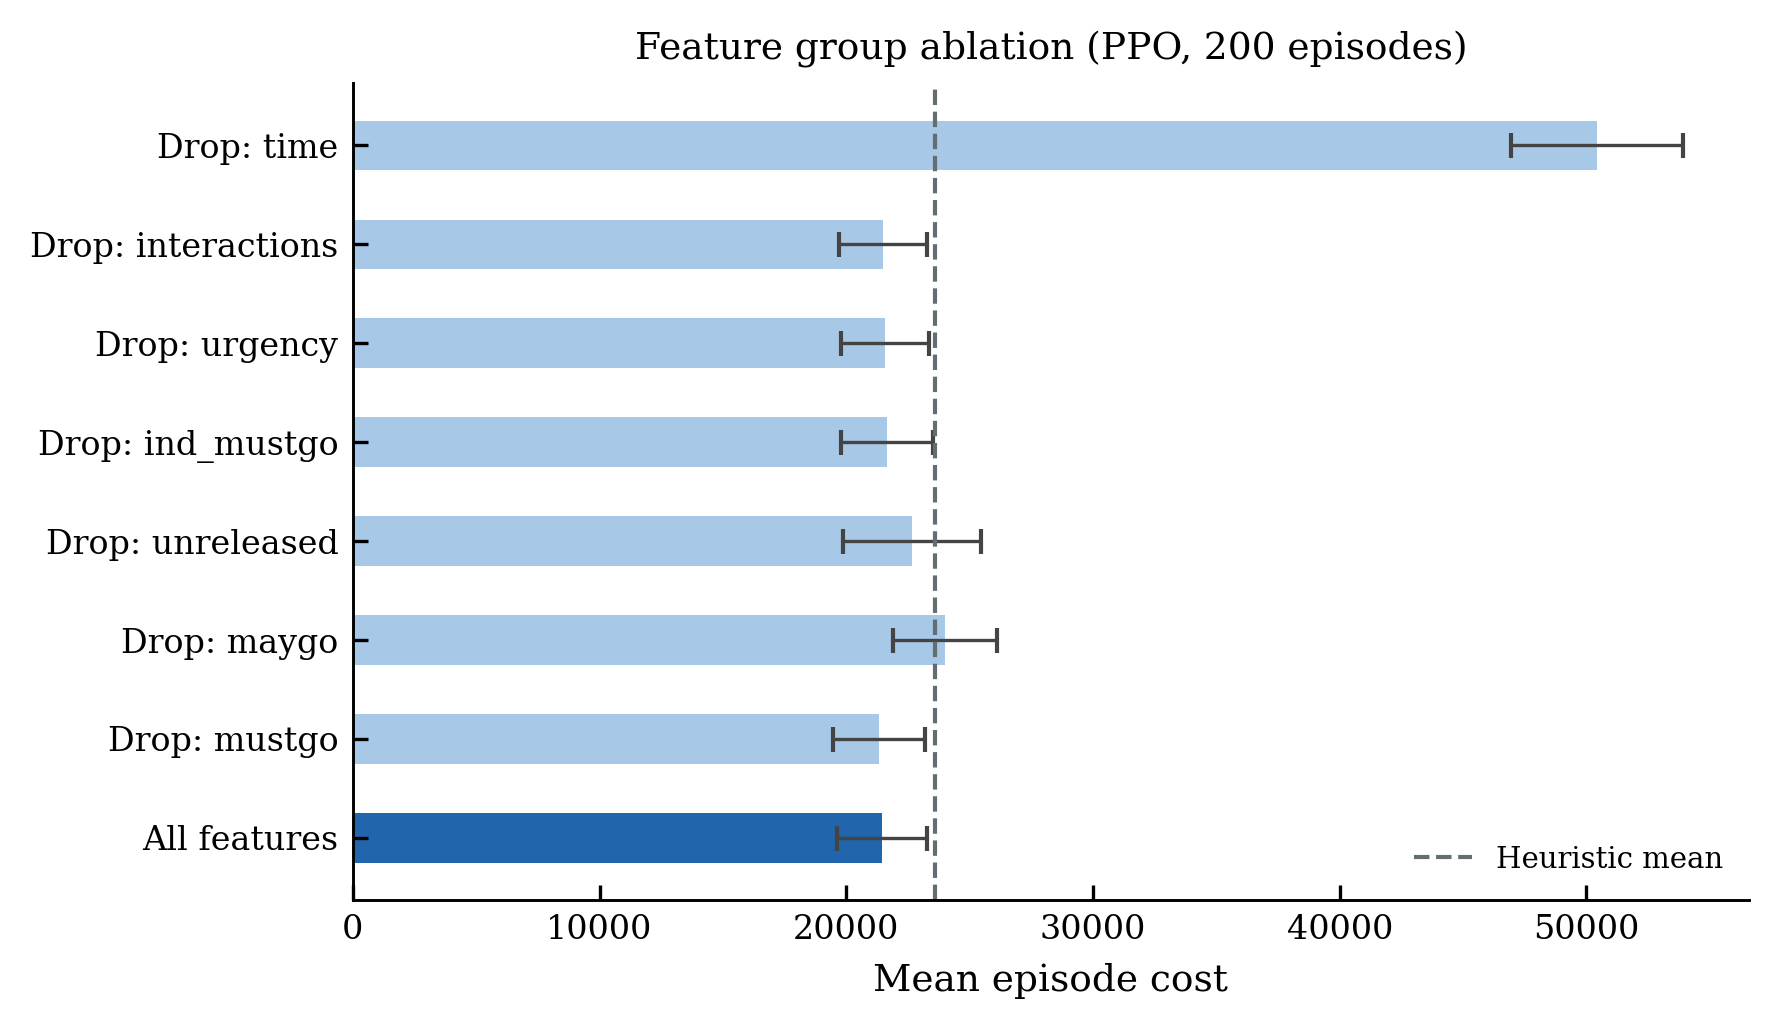

In [42]:
# Define feature groups
D   = env_train.D
_n  = D*(D-1)//2 + (1 if D==3 else 0)

FEATURE_GROUPS = {
    'mustgo':       slice(0,        D),
    'maygo':        slice(D,        2*D),
    'unreleased':   slice(2*D,      3*D),
    'ind_mustgo':   slice(3*D,      4*D),
    'urgency':      slice(4*D,      5*D),
    'interactions': slice(5*D,      5*D + _n),
    'time':         slice(5*D + _n, None),       # total, t, steps_remaining
}

names = vfa_feature_names(env_train)
for grp, sl in FEATURE_GROUPS.items():
    print(f"{grp:>15}: {names[sl]}")
    
class DDPEnvFeatAblated(DDPEnvFeat):
    """DDPEnvFeat with a subset of features zeroed out."""
    def __init__(self, config, drop_groups=()):
        super().__init__(config)
        self.drop_groups = drop_groups

    def _obs(self):
        obs = super()._obs().copy()
        for g in self.drop_groups:
            obs[FEATURE_GROUPS[g]] = 0.0
        return obs

class AblationLogger(BaseCallback):
    def __init__(self, tag, print_freq=50_000):
        super().__init__()
        self.tag        = tag
        self.print_freq = print_freq

    def _on_step(self):
        if self.n_calls % self.print_freq == 0:
            # collect any finished episodes across all envs
            ep_returns = [
                info['episode']['r']
                for info in self.locals.get('infos', [])
                if 'episode' in info
            ]
            if ep_returns:
                print(f"  [{self.tag}]  step {self.n_calls:>8,}  |  "
                      f"mean ep return: {np.mean(ep_returns):>9.1f}")
            else:
                print(f"  [{self.tag}]  step {self.n_calls:>8,}  |  "
                      f"(no episode finished this window)")
        return True


def train_ppo_ablation(drop_groups=(), total_steps=50_000, seed=0, tag=''):
    label  = tag or f"drop={drop_groups}"
    env_fn = lambda: DDPEnvFeatAblated(config, drop_groups=drop_groups)
    vec    = make_vec_env(env_fn, n_envs=4, seed=seed)
    vec    = VecNormalize(vec, norm_obs=False, norm_reward=True, clip_reward=10.0)
    model  = PPO(
        'MlpPolicy', vec,
        learning_rate=3e-4, n_steps=112, batch_size=64,
        n_epochs=10, gamma=1.0, gae_lambda=0.95,
        clip_range=0.2, ent_coef=0.005,
        policy_kwargs=dict(net_arch=dict(pi=[128,128], vf=[128,128])),
        verbose=0, seed=seed,
    )
    print(f"\n── Starting: {label} ──")
    model.learn(total_timesteps=total_steps,
                callback=AblationLogger(tag=label, print_freq=50_000))

    def policy_fn(env, obs):
        act, _ = model.predict(obs, deterministic=True)
        return act
    costs = eval_policy(policy_fn, n_ep=200)
    print(f"  [{label}]  DONE  mean={costs.mean():.1f}  std={costs.std():.1f}")
    return costs

ablation_feature_results = {}

# Baseline
ablation_feature_results['All features'] = train_ppo_ablation(
    drop_groups=(), tag='All features')

# Drop one group at a time
for group in FEATURE_GROUPS:
    ablation_feature_results[f'Drop: {group}'] = train_ppo_ablation(
        drop_groups=(group,), tag=f'Drop: {group}')



# Step 8: analyze an document

In [44]:
def collect_trajectories(policy_fn, n_ep=200, seed=999):
    """Record (t, state_features, action, cost) for every step."""
    env   = DDPEnvFeat(config)
    rows  = []
    for ep in range(n_ep):
        obs, _ = env.reset(seed=seed + ep)
        while True:
            act              = policy_fn(env, obs)
            # record before stepping
            s                = env.state.copy()
            mustgo           = s[:, 0, 0]
            maygo            = s[:, 0, 1:].sum(axis=1)
            t                = int(env.t)
            obs2, _, term, trunc, info = env.step(act)
            rows.append({
                'episode':   ep,
                't':         t,
                'cost':      info['cost'],
                'action':    act.copy(),          # shape (D,)
                'mustgo':    mustgo.copy(),
                'maygo':     maygo.copy(),
                'total_inv': float(s.sum()),
            })
            obs = obs2
            if term or trunc:
                break
    return pd.DataFrame(rows)

print("Collecting trajectories …")
df_ppo = collect_trajectories(wrap_ppo,       n_ep=200); df_ppo['policy'] = 'PPO'
df_heu = collect_trajectories(wrap_heuristic, n_ep=200); df_heu['policy'] = 'Heuristic'
df     = pd.concat([df_ppo, df_heu], ignore_index=True)

In [48]:
dest_names = env_train.dest_names  # ['R', 'G', 'B']

for dframe in [df_ppo, df_heu]:
    for i, name in enumerate(dest_names):
        dframe[f'act_{name}']    = dframe['action'].apply(lambda a, i=i: a[i])
        dframe[f'mustgo_{name}'] = dframe['mustgo'].apply(lambda m, i=i: m[i])
        dframe[f'maygo_{name}']  = dframe['maygo'].apply(lambda m, i=i: m[i])
    dframe['total_loaded'] = dframe['action'].apply(lambda a: a.sum())

# Rebuild df from the now-enriched dataframes
df = pd.concat([df_ppo, df_heu], ignore_index=True)

# Verify
print("act_ columns:", [c for c in df_ppo.columns if c.startswith('act_')])
print("sample act_R:", df_ppo['act_R'].iloc[0])

act_ columns: ['act_R', 'act_G', 'act_B']
sample act_R: 5.829222


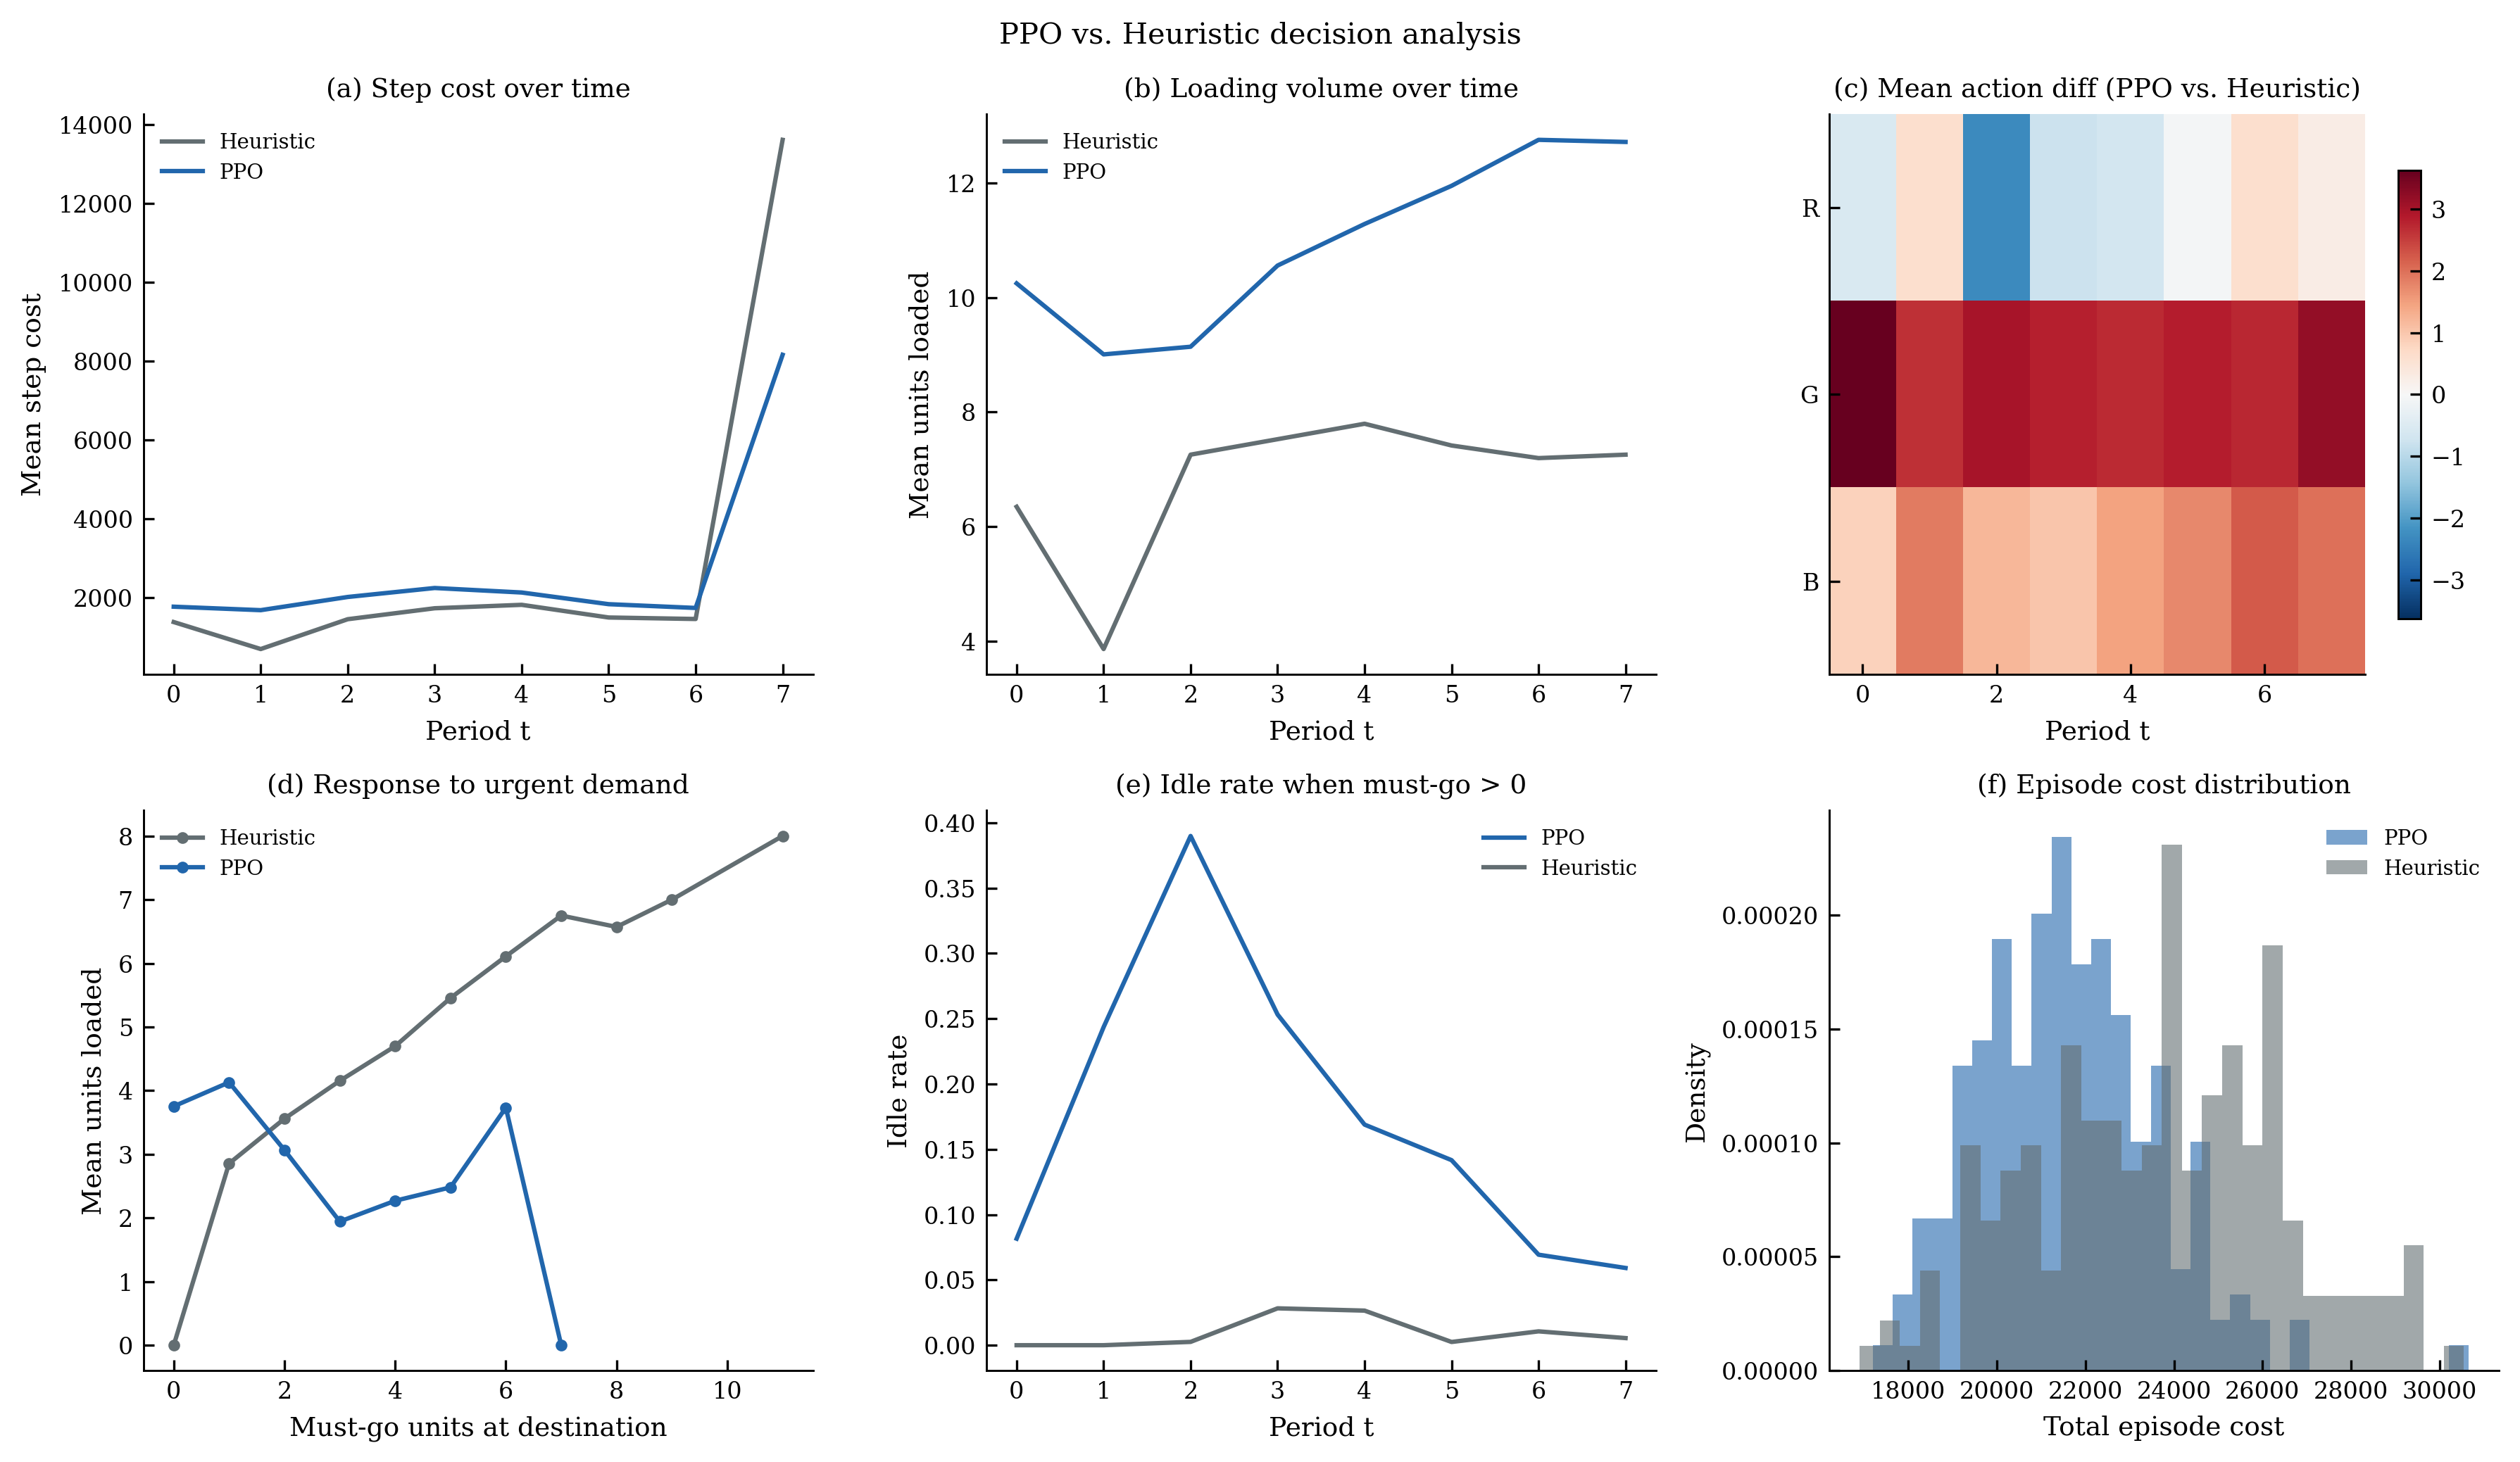

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.suptitle('PPO vs. Heuristic decision analysis', fontsize=10)

# ── (a) Cost over time
ax = axes[0, 0]
for label, grp in df.groupby('policy'):
    mn = grp.groupby('t')['cost'].mean()
    ax.plot(mn.index, mn.values, label=label,
            color='#2166ac' if label == 'PPO' else '#636e72', lw=1.5)
ax.set_xlabel('Period t'); ax.set_ylabel('Mean step cost')
ax.set_title('(a) Step cost over time')
ax.legend(frameon=False, fontsize=7)

# ── (b) Total loaded per step
ax = axes[0, 1]
for label, grp in df.groupby('policy'):
    mn = grp.groupby('t')['total_loaded'].mean()
    ax.plot(mn.index, mn.values, label=label,
            color='#2166ac' if label == 'PPO' else '#636e72', lw=1.5)
ax.set_xlabel('Period t'); ax.set_ylabel('Mean units loaded')
ax.set_title('(b) Loading volume over time')
ax.legend(frameon=False, fontsize=7)

# ── (c) Action difference heatmap (PPO - Heuristic)
ax = axes[0, 2]
diff_rows = []
for name in dest_names:
    ppo_mean = df_ppo.groupby('t')[f'act_{name}'].mean()
    heu_mean = df_heu.groupby('t')[f'act_{name}'].mean()
    diff_rows.append((ppo_mean - heu_mean).values)
diff_mat = np.array(diff_rows)
im = ax.imshow(diff_mat, aspect='auto', cmap='RdBu_r',
               vmin=-np.abs(diff_mat).max(), vmax=np.abs(diff_mat).max())
ax.set_yticks(range(D)); ax.set_yticklabels(dest_names)
ax.set_xlabel('Period t'); ax.set_title('(c) Mean action diff (PPO vs. Heuristic)')
plt.colorbar(im, ax=ax, shrink=0.8)

# ── (d) Urgency vs action scatter
ax = axes[1, 0]
for label, grp in df.groupby('policy'):
    # pool all destinations
    urg = np.concatenate([grp[f'mustgo_{n}'].values for n in dest_names])
    act = np.concatenate([grp[f'act_{n}'].values    for n in dest_names])
    # bin by urgency
    bins  = np.arange(0, urg.max() + 2)
    means = [act[urg == v].mean() for v in bins if (urg == v).sum() > 0]
    xs    = [v for v in bins if (urg == v).sum() > 0]
    ax.plot(xs, means, label=label,
            color='#2166ac' if label == 'PPO' else '#636e72',
            lw=1.5, marker='o', ms=3)
ax.set_xlabel('Must-go units at destination')
ax.set_ylabel('Mean units loaded')
ax.set_title('(d) Response to urgent demand')
ax.legend(frameon=False, fontsize=7)

# ── (e) Idle rate (action=0 when mustgo>0)
ax = axes[1, 1]
for label, (grp, col) in zip(
        ['PPO', 'Heuristic'],
        [(df_ppo, '#2166ac'), (df_heu, '#636e72')]):
    idle_by_t = []
    for t, tgrp in grp.groupby('t'):
        mask  = np.concatenate([tgrp[f'mustgo_{n}'].values for n in dest_names]) > 0
        acted = np.concatenate([tgrp[f'act_{n}'].values    for n in dest_names])
        idle_rate = (acted[mask] == 0).mean() if mask.sum() > 0 else np.nan
        idle_by_t.append((t, idle_rate))
    ts, ir = zip(*idle_by_t)
    ax.plot(ts, ir, label=label, color=col, lw=1.5)
ax.set_xlabel('Period t'); ax.set_ylabel('Idle rate')
ax.set_title('(e) Idle rate when must-go > 0')
ax.legend(frameon=False, fontsize=7)

# ── (f) Episode cost distribution
ax = axes[1, 2]
for label, grp, col in [('PPO', df_ppo, '#2166ac'), ('Heuristic', df_heu, '#636e72')]:
    ep_costs = grp.groupby('episode')['cost'].sum()
    ax.hist(ep_costs, bins=30, alpha=0.6, color=col, label=label, density=True)
ax.set_xlabel('Total episode cost'); ax.set_ylabel('Density')
ax.set_title('(f) Episode cost distribution')
ax.legend(frameon=False, fontsize=7)

plt.tight_layout()
plt.savefig('ppo_vs_heuristic_analysis.pdf', dpi=300, bbox_inches='tight')
plt.savefig('ppo_vs_heuristic_analysis.png', dpi=300, bbox_inches='tight')
plt.show()